# PRACTICA 1

## Descarga del dataset de Roboflow

In [1]:
from roboflow import Roboflow

In [2]:
rf = Roboflow(api_key="9s14SLhHBziZ15qOFgZ0")
project = rf.workspace("garbage-detection-nalan").project("garbage-euqch")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


In [3]:
print(f"Dataset descargado en: {dataset.location}")

Dataset descargado en: C:\Users\VALERIA\Documents\DIPLOMADO\Modulo 4\Laboratorio 1\Garbage-1


In [4]:
import yaml

with open(f"C:/Users/VALERIA/Documents/DIPLOMADO/Modulo 4/Laboratorio 1/Garbage-1/data.yaml", 'r') as f:
    data_config = yaml.safe_load(f)
    print("Clases:", data_config.get('names', {}))

Clases: ['battery', 'cardboard', 'clothes', 'glass', 'metal', 'miscellaneous trash', 'organic', 'paper', 'plastic', 'shoes']


## Información para recolección y anotación de datos

### Cantidad de imagenes del Dataset

In [5]:
import os

dataset_path = dataset.location

train_count = len(os.listdir(f"{dataset_path}/train/images"))
valid_count = len(os.listdir(f"{dataset_path}/valid/images"))
test_count  = len(os.listdir(f"{dataset_path}/test/images"))

print("Distribución del dataset:")
print(f"  Train : {train_count} imágenes ({train_count/(train_count+valid_count+test_count)*100:.1f}%)")
print(f"  Valid : {valid_count} imágenes ({valid_count/(train_count+valid_count+test_count)*100:.1f}%)")
print(f"  Test  : {test_count}  imágenes ({test_count/(train_count+valid_count+test_count)*100:.1f}%)")
print(f"  Total : {train_count + valid_count + test_count} imágenes")

Distribución del dataset:
  Train : 4259 imágenes (70.1%)
  Valid : 1200 imágenes (19.8%)
  Test  : 616  imágenes (10.1%)
  Total : 6075 imágenes


### Mostrar las clases anotadas

In [6]:
import yaml

with open(f"{dataset.location}/data.yaml", 'r') as f:
    data_config = yaml.safe_load(f)

print("Clases del dataset (categorías de basura):")
for i, nombre in enumerate(data_config.get('names', [])):
    print(f"  Clase {i}: {nombre}")
print(f"\nTotal de clases: {data_config.get('nc', '?')}")

Clases del dataset (categorías de basura):
  Clase 0: battery
  Clase 1: cardboard
  Clase 2: clothes
  Clase 3: glass
  Clase 4: metal
  Clase 5: miscellaneous trash
  Clase 6: organic
  Clase 7: paper
  Clase 8: plastic
  Clase 9: shoes

Total de clases: 10


### Mostrar ejemplos de imágenes del dataset

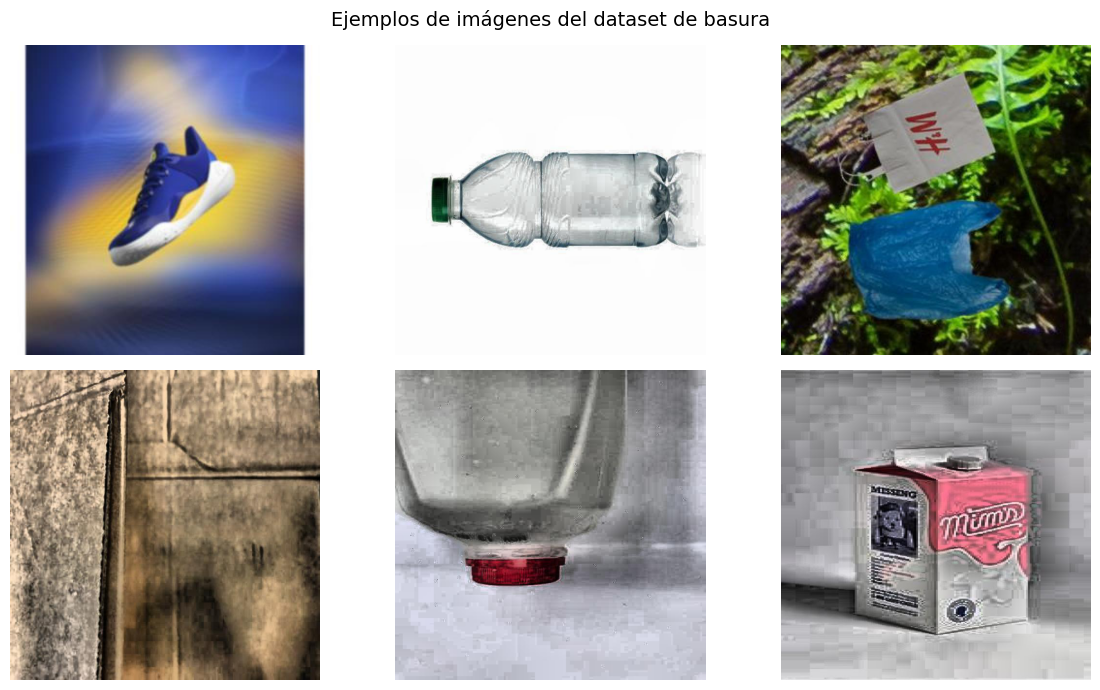

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

img_folder = f"{dataset_path}/train/images"
imagenes = random.sample(os.listdir(img_folder), 6)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
fig.suptitle("Ejemplos de imágenes del dataset de basura", fontsize=14)

for ax, img_name in zip(axes.flatten(), imagenes):
    img = mpimg.imread(f"{img_folder}/{img_name}")
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Distribución de clases (gráfico)

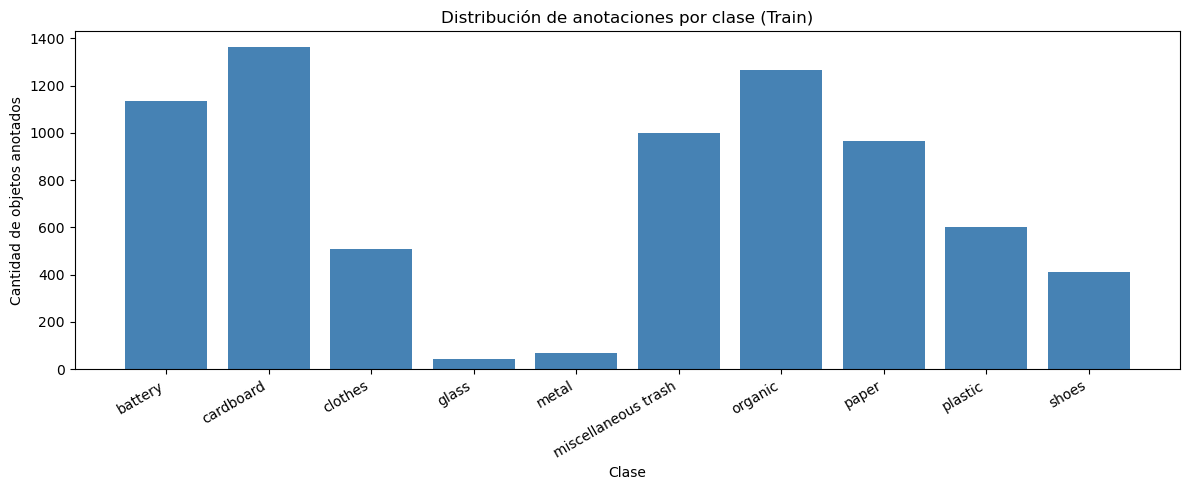

In [8]:
import glob
from collections import Counter
import matplotlib.pyplot as plt

label_folder = f"{dataset_path}/train/labels"
class_counts = Counter()

for label_file in glob.glob(f"{label_folder}/*.txt"):
    with open(label_file) as f:
        for line in f:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

nombres = data_config.get('names', [])
etiquetas = [nombres[i] for i in sorted(class_counts)]
valores = [class_counts[i] for i in sorted(class_counts)]

plt.figure(figsize=(12, 5))
plt.bar(etiquetas, valores, color='steelblue')
plt.title("Distribución de anotaciones por clase (Train)")
plt.xlabel("Clase")
plt.ylabel("Cantidad de objetos anotados")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Verificación de la configuración de aumento de datos

In [14]:
import sys
!{sys.executable} -m pip install ultralytics

In [1]:
from ultralytics import YOLO

OSError: [WinError 182] El sistema operativo no puede ejecutar %1. Error loading "C:\Users\VALERIA\.conda\envs\diplomado_env\Lib\site-packages\torch\lib\fbgemm.dll" or one of its dependencies.

In [12]:
from ultralytics import YOLO

# Cargar modelo para ver sus parámetros por defecto
model = YOLO("yolov10n.pt")

print("="*50)
print("PARÁMETROS DE AUMENTO DE DATOS (YOLO)")
print("="*50)

# Mostrar parámetros de incremento
aug_params = {
    'hsv_h': 0.015,
    'hsv_s': 0.7,
    'hsv_v': 0.4,
    'degrees': 0.0,
    'translate': 0.1,
    'scale': 0.5,
    'shear': 0.0,
    'perspective': 0.0,
    'flipud': 0.0,
    'fliplr': 0.5,
    'mosaic': 1.0,
    'mixup': 0.0
}

print("\nParámetros de aumento de datos:")
for key, value in aug_params.items():
    print(f"   {key}: {value}")

print("\nLos incrementos se aplicarán automáticamente durante el entrenamiento")

ModuleNotFoundError: No module named 'ultralytics'

## Entrenamiento del modelo

In [21]:
# Cargar modelo pre-entrenado
model = YOLO("yolov10n.pt")

# Entrenar el modelo con el dataset de residuos
results = model.train(
    data="/content/Garbage-1/data.yaml",  # Ruta del dataset
    epochs=10,                             # Número de epochs
    batch=16,                              # Tamaño del batch
    imgsz=640,                             # Tamaño de las imágenes
    plots=True,                            # Generar gráficos
    device='cpu',                          # CPU 
    name='waste_detection'                 # Nombre de la carpeta de resultados
)

print("\nEntrenamiento completado")

NameError: name 'YOLO' is not defined